# 02 — Noise Robustness and Opponent Geometry

Central question: expectile and quantile learning are both valid
distributional-RL targets at convergence, but does either one hold up
better under a noisy learning signal — the realistic case, given that
reward and RPE signals are noisy in the brain?

Two things are tracked together because they turn out to share a cause:
1. the abstraction-index gap between expectile and quantile as learning
   noise increases (does one degrade faster than the other?),
2. whether each rule produces D1/D2-like opponent geometry at all, at
   each noise level.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, ttest_ind, sem

import rw_utils as rwu

ARTIFACT_DIR = "artifacts"
const = np.load(os.path.join(ARTIFACT_DIR, "empirical_constants.npz"))
EMP_AI = dict(zip(const["stat_names"], const["ai_mean"]))
EMP_COS = dict(zip(const["stat_names"], const["cos_align_mean"]))
L_POOLED = const["L_pooled"]
N_UNITS_RW = int(const["n_units_rw"])
OBS_NOISE_SD = float(const["obs_noise_sd"])
N_TRIALS_PER_ODOR = int(const["median_trials_per_condition"])
N_PROBE = max(5, N_TRIALS_PER_ODOR // 2)

print(f"Loaded empirical constants: AI={dict((k, round(float(v), 3)) for k, v in EMP_AI.items())}")
print(f"RW population size (matches noise calibration): {N_UNITS_RW}")
print(f"Trial regime from real data: {N_TRIALS_PER_ODOR} trials/odor, probing last {N_PROBE}")

Loaded empirical constants: AI={np.str_('mean'): 0.623, np.str_('variance'): 0.098, np.str_('kurtosis'): 0.006}
RW population size (matches noise calibration): 50
Trial regime from real data: 35 trials/odor, probing last 17


## Discrete noise conditions: clean / noisy learning signal / noisy learning + observation

In [2]:
N_SEEDS = 30
RULES = ["expectile", "quantile"]
NOISE_CONDITIONS = {
    "clean":       dict(learn_noise_sd=0.0, L_obs=None),
    "noisy_learn": dict(learn_noise_sd=1.5, L_obs=None),
    "noisy_both":  dict(learn_noise_sd=1.5, L_obs=L_POOLED),
}

def run_condition(rule, learn_noise_sd, L_obs, seed):
    alpha_plus, alpha_minus, taus = rwu.sample_alphas(N_UNITS_RW, seed=seed)
    probe_main = rwu.train_rw_probed("SameRewDist", alpha_plus, alpha_minus, rule=rule,
                                      n_trials_per_odor=N_TRIALS_PER_ODOR, n_probe=N_PROBE,
                                      learn_noise_sd=learn_noise_sd, L_obs=L_obs, seed=seed)
    probe_srv = rwu.train_rw_probed("SameRewVar", alpha_plus, alpha_minus, rule=rule,
                                     n_trials_per_odor=N_TRIALS_PER_ODOR, n_probe=N_PROBE,
                                     learn_noise_sd=learn_noise_sd, L_obs=L_obs, seed=seed + 100_000)
    out = []
    for stat, c in rwu.CONTRASTS_RW.items():
        probe = probe_main if c["task"] == "SameRewDist" else probe_srv
        cr = rwu.build_cr_from_probes(probe)
        res = rwu.cross_identity_decode(cr, np.arange(cr.shape[1]), c["neg"], c["pos"], 0, seed=seed)
        if res is None:
            continue
        cross, within, _ = res
        out.append(dict(stat=stat, ai=rwu.abstraction_index(cross, within)))
    # opponency from the mean converged (probed) value estimate
    V_conv = probe_main.mean(axis=2)
    d1n, d2n = np.where(taus > 0.5)[0], np.where(taus <= 0.5)[0]
    opp_d1 = rwu.nothing_relative_distance_V(V_conv, d1n) if len(d1n) >= 2 else np.nan
    opp_d2 = rwu.nothing_relative_distance_V(V_conv, d2n) if len(d2n) >= 2 else np.nan
    return out, opp_d1, opp_d2

cond_rows, opp_rows = [], []
for rule in RULES:
    for cond_name, kw in NOISE_CONDITIONS.items():
        for seed in range(N_SEEDS):
            stats_out, opp_d1, opp_d2 = run_condition(rule, kw["learn_noise_sd"], kw["L_obs"], seed)
            for s in stats_out:
                cond_rows.append(dict(rule=rule, condition=cond_name, seed=seed, **s))
            opp_rows.append(dict(rule=rule, condition=cond_name, seed=seed, opp_d1=opp_d1, opp_d2=opp_d2))

df_cond = pd.DataFrame(cond_rows)
df_opp_cond = pd.DataFrame(opp_rows)

print("Mean AI by rule x condition x stat:")
print(df_cond.groupby(["rule", "condition", "stat"])["ai"].mean().unstack("stat").to_string(float_format=lambda v: f"{v:.3f}"))

Mean AI by rule x condition x stat:
stat                   kurtosis  mean  variance
rule      condition                            
expectile clean          -0.012 0.796     0.026
          noisy_both     -0.015 0.525     0.010
          noisy_learn    -0.016 0.816     0.004
quantile  clean          -0.018 0.756     0.160
          noisy_both      0.003 0.328     0.007
          noisy_learn    -0.009 0.563     0.006


In [3]:
print("Expectile - quantile AI gap (t-test across seeds):")
gap_rows = []
for cond in NOISE_CONDITIONS:
    for stat in rwu.CONTRASTS_RW:
        e = df_cond[(df_cond.rule == "expectile") & (df_cond.condition == cond) & (df_cond.stat == stat)]["ai"]
        q = df_cond[(df_cond.rule == "quantile") & (df_cond.condition == cond) & (df_cond.stat == stat)]["ai"]
        if len(e) < 2 or len(q) < 2:
            continue
        _, p = ttest_ind(e, q)
        gap = e.mean() - q.mean()
        gap_rows.append(dict(condition=cond, stat=stat, exp_ai=e.mean(), quant_ai=q.mean(), gap=gap, p=p))
        print(f"  {cond:12s} {stat:10s}  exp={e.mean():+.3f}  quant={q.mean():+.3f}  gap={gap:+.3f}  p={p:.3f}")
df_gap = pd.DataFrame(gap_rows)

Expectile - quantile AI gap (t-test across seeds):
  clean        mean        exp=+0.796  quant=+0.756  gap=+0.040  p=0.078
  clean        variance    exp=+0.026  quant=+0.160  gap=-0.134  p=0.000
  clean        kurtosis    exp=-0.012  quant=-0.018  gap=+0.006  p=0.855
  noisy_learn  mean        exp=+0.816  quant=+0.563  gap=+0.254  p=0.000
  noisy_learn  variance    exp=+0.004  quant=+0.006  gap=-0.002  p=0.947
  noisy_learn  kurtosis    exp=-0.016  quant=-0.009  gap=-0.006  p=0.849
  noisy_both   mean        exp=+0.525  quant=+0.328  gap=+0.198  p=0.000
  noisy_both   variance    exp=+0.010  quant=+0.007  gap=+0.003  p=0.953
  noisy_both   kurtosis    exp=-0.015  quant=+0.003  gap=-0.019  p=0.629


## Continuous noise sweep: does the gap scale with noise, and does opponency survive it?

In [4]:
LEARN_NOISE_SWEEP = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
N_SEEDS_SWEEP = 15

sweep_rows, opp_sweep_rows = [], []
for ln_sd in LEARN_NOISE_SWEEP:
    for rule in RULES:
        for seed in range(N_SEEDS_SWEEP):
            alpha_plus, alpha_minus, taus = rwu.sample_alphas(N_UNITS_RW, seed=seed)
            probe = rwu.train_rw_probed("SameRewDist", alpha_plus, alpha_minus, rule=rule,
                                         n_trials_per_odor=N_TRIALS_PER_ODOR, n_probe=N_PROBE,
                                         learn_noise_sd=ln_sd, seed=seed)
            cr = rwu.build_cr_from_probes(probe)
            for stat, neg, pos in [("mean", rwu.NOTHING_IDX, rwu.FIXED_IDX),
                                    ("variance", rwu.FIXED_IDX, rwu.VARIABLE_IDX)]:
                res = rwu.cross_identity_decode(cr, np.arange(cr.shape[1]), neg, pos, 0, seed=seed)
                if res is None:
                    continue
                cross, within, _ = res
                sweep_rows.append(dict(rule=rule, learn_noise_sd=ln_sd, stat=stat, seed=seed,
                                        ai=rwu.abstraction_index(cross, within)))

            V_conv = probe.mean(axis=2)
            d1n, d2n = np.where(taus > 0.5)[0], np.where(taus <= 0.5)[0]
            if len(d1n) < 2 or len(d2n) < 2:
                continue
            opp_sweep_rows.append(dict(rule=rule, learn_noise_sd=ln_sd, seed=seed,
                                        d1_delta=rwu.nothing_relative_distance_V(V_conv, d1n),
                                        d2_delta=rwu.nothing_relative_distance_V(V_conv, d2n)))

df_sweep = pd.DataFrame(sweep_rows)
df_opp_sweep = pd.DataFrame(opp_sweep_rows)

mean_ai = df_sweep[df_sweep.stat == "mean"].groupby(["rule", "learn_noise_sd"])["ai"].agg(["mean", "sem"])
print("Mean-contrast AI by rule x noise level:")
print(mean_ai.to_string(float_format=lambda v: f"{v:.3f}"))

Mean-contrast AI by rule x noise level:
                          mean   sem
rule      learn_noise_sd            
expectile 0.0            0.815 0.019
          0.5            0.827 0.019
          1.0            0.835 0.022
          1.5            0.837 0.023
          2.0            0.838 0.021
          2.5            0.828 0.021
quantile  0.0            0.776 0.022
          0.5            0.750 0.020
          1.0            0.684 0.021
          1.5            0.580 0.025
          2.0            0.475 0.022
          2.5            0.364 0.032


In [5]:
print("Expectile - quantile mean-AI gap by noise level:")
gap_by_noise = []
for ln_sd in LEARN_NOISE_SWEEP:
    e = df_sweep[(df_sweep.rule == "expectile") & (df_sweep.learn_noise_sd == ln_sd) & (df_sweep.stat == "mean")]["ai"]
    q = df_sweep[(df_sweep.rule == "quantile") & (df_sweep.learn_noise_sd == ln_sd) & (df_sweep.stat == "mean")]["ai"]
    _, p = ttest_ind(e, q)
    gap_by_noise.append(dict(noise=ln_sd, exp=e.mean(), quant=q.mean(), gap=e.mean() - q.mean(), p=p))
    print(f"  noise={ln_sd:.1f}  exp={e.mean():.3f}  quant={q.mean():.3f}  gap={e.mean()-q.mean():+.3f}  p={p:.4f}")
df_gap_by_noise = pd.DataFrame(gap_by_noise)

print("\nOpponent geometry by rule x noise level:")
opp_by_noise = []
for ln_sd in LEARN_NOISE_SWEEP:
    for rule in RULES:
        sub = df_opp_sweep[(df_opp_sweep.rule == rule) & (df_opp_sweep.learn_noise_sd == ln_sd)]
        if len(sub) < 2:
            continue
        _, p1 = ttest_1samp(sub["d1_delta"], 0)
        _, p2 = ttest_1samp(sub["d2_delta"], 0)
        opponent = bool(sub["d1_delta"].mean() > 0 and sub["d2_delta"].mean() < 0)
        opp_by_noise.append(dict(rule=rule, noise=ln_sd, d1_delta=sub["d1_delta"].mean(),
                                  d2_delta=sub["d2_delta"].mean(), opponent=opponent))
        print(f"  {rule:10s} noise={ln_sd:.1f}  D1={sub['d1_delta'].mean():+.3f} (p={p1:.2e})"
              f"  D2={sub['d2_delta'].mean():+.3f} (p={p2:.2e})  opponent={opponent}")
df_opp_by_noise = pd.DataFrame(opp_by_noise)

Expectile - quantile mean-AI gap by noise level:
  noise=0.0  exp=0.815  quant=0.776  gap=+0.039  p=0.1904
  noise=0.5  exp=0.827  quant=0.750  gap=+0.077  p=0.0105
  noise=1.0  exp=0.835  quant=0.684  gap=+0.151  p=0.0000
  noise=1.5  exp=0.837  quant=0.580  gap=+0.257  p=0.0000
  noise=2.0  exp=0.838  quant=0.475  gap=+0.364  p=0.0000
  noise=2.5  exp=0.828  quant=0.364  gap=+0.464  p=0.0000

Opponent geometry by rule x noise level:
  expectile  noise=0.0  D1=+1.382 (p=3.03e-04)  D2=-0.317 (p=2.77e-01)  opponent=True
  quantile   noise=0.0  D1=-2.320 (p=1.21e-07)  D2=-1.483 (p=1.39e-05)  opponent=False
  expectile  noise=0.5  D1=+0.941 (p=1.23e-02)  D2=-0.620 (p=4.88e-02)  opponent=True
  quantile   noise=0.5  D1=-1.963 (p=1.34e-06)  D2=-1.504 (p=2.84e-05)  opponent=False
  expectile  noise=1.0  D1=+0.763 (p=3.79e-02)  D2=-0.779 (p=2.17e-02)  opponent=True
  quantile   noise=1.0  D1=-1.272 (p=3.14e-04)  D2=-1.188 (p=6.07e-04)  opponent=False
  expectile  noise=1.5  D1=+0.599 (p=9.97e

## Figures

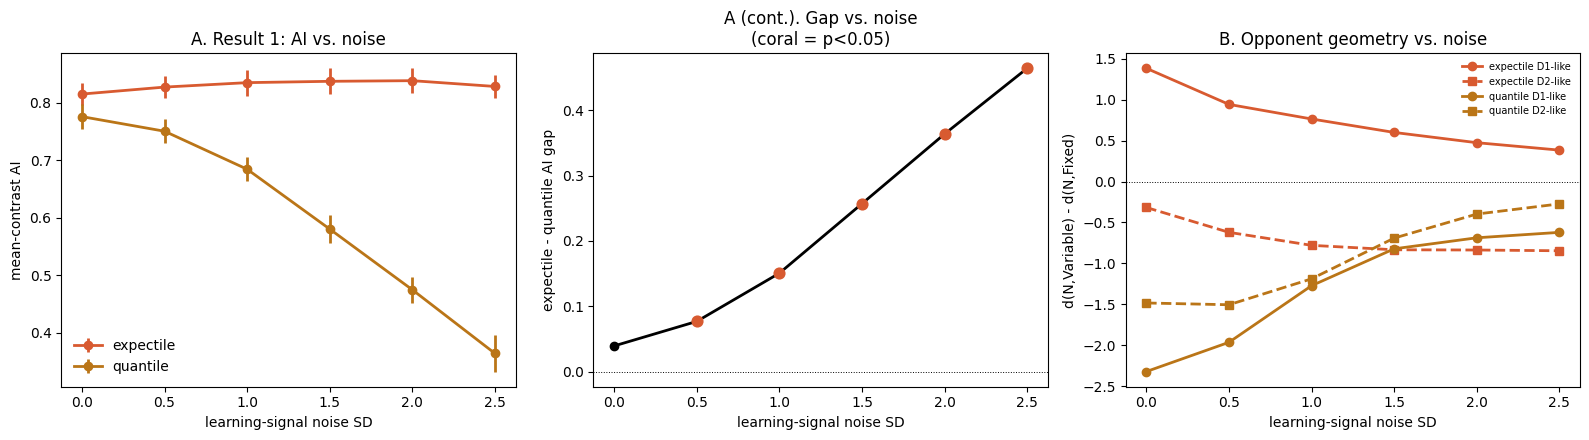

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
for rule in RULES:
    sub = mean_ai.loc[rule]
    ax.errorbar(LEARN_NOISE_SWEEP, sub["mean"], yerr=sub["sem"], marker="o",
                color=rwu.RULE_COLORS[rule], label=rule, lw=2)
ax.set_xlabel("learning-signal noise SD"); ax.set_ylabel("mean-contrast AI")
ax.set_title("A. Result 1: AI vs. noise")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(df_gap_by_noise["noise"], df_gap_by_noise["gap"], marker="o", color="k", lw=2)
ax.axhline(0, color="k", lw=0.7, ls=":")
for _, row in df_gap_by_noise.iterrows():
    if row["p"] < 0.05:
        ax.scatter([row["noise"]], [row["gap"]], color=rwu.CORAL, zorder=3, s=60)
ax.set_xlabel("learning-signal noise SD"); ax.set_ylabel("expectile - quantile AI gap")
ax.set_title("A (cont.). Gap vs. noise\n(coral = p<0.05)")

ax = axes[2]
for rule in RULES:
    sub = df_opp_by_noise[df_opp_by_noise.rule == rule]
    ax.plot(sub["noise"], sub["d1_delta"], marker="o", color=rwu.RULE_COLORS[rule], lw=2, label=f"{rule} D1-like")
    ax.plot(sub["noise"], sub["d2_delta"], marker="s", ls="--", color=rwu.RULE_COLORS[rule], lw=2, label=f"{rule} D2-like")
ax.axhline(0, color="k", lw=0.7, ls=":")
ax.set_xlabel("learning-signal noise SD"); ax.set_ylabel("d(N,Variable) - d(N,Fixed)")
ax.set_title("B. Opponent geometry vs. noise")
ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
fig_dir = os.path.join(ARTIFACT_DIR, "..", "figures")
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(os.path.join(fig_dir, "02_noise_robustness.pdf"), bbox_inches="tight")
plt.show()

df_cond.to_csv(os.path.join(ARTIFACT_DIR, "noise_discrete_conditions.csv"), index=False)
df_sweep.to_csv(os.path.join(ARTIFACT_DIR, "noise_sweep_ai.csv"), index=False)
df_opp_sweep.to_csv(os.path.join(ARTIFACT_DIR, "noise_sweep_opponency.csv"), index=False)